In [1]:
import pandas as pd
import torch
import numpy as np
import seaborn as sns
import tqdm.auto as tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
_cost = {
    "localdiffdock": 407.5,
    "diffdock": 407.5,
    "flexx": 3.33,
    "smina": 99.9,
    "gnina": 105.8,
    "plants": 6.85,
    "cnnscore": 0.31,
    "cnnaffinity": 0.31,
    "smina_affinity": 0.31,
    "ad4": 0.28,
    "linf9": 0.24,
    "rtmscore": 0.41,
    "vinardo": 0.29,
    "scorch": 4.63,
    "hyde": 2.0,
    "chemplp": 0.121,
    "rfscore_v1": 0.682,
    "rfscore_v2": 0.687,
    "rfscore_v3": 0.69,
    "vina_hydrophobic": 0.69,
    "vina_intra_hydrophobic": 0.69,
}

In [200]:
# df_orig = pd.read_csv("egfr_data/results/all_rescoring_results_merged.csv")
df_orig = pd.read_csv("ecft_data/all_rescoring_results_ecft.csv")

def augment_df(df):
    features = [
        col
        for col in df.columns
        if col
        not in ["docking_method", "pose", "ID", "id", "docking_tool", "activity_class"]
    ]
    df[features] = df[features].apply(pd.to_numeric, errors="coerce")
    scaler = StandardScaler()
    df[features] = scaler.fit_transform(df[features])
    df.dropna(subset=features, inplace=True)
    df["pose"] = df["ID"].apply(lambda x: x.split("_")[2]).astype(int) - 1

augment_df(df_orig)
df_orig

,ID,CNNscore,CNNaffinity,LinF9,RTMScore,SCORCH,CHEMPLP,rfscore_v1,rfscore_v3,vina_hydrophobic,vina_intra_hydrophobic,HYDE,id,docking_tool,true_value,activity_class,pose
0,HIPS7013_flexx_010,1.067467,0.889748,-0.479802,0.208534,0.420737,-1.152124,0.801973,-0.363996,-0.601206,0.923753,-0.050510,HIPS7013,flexx,-0.621637,0,9
1,HIPS7010_flexx_001,-0.259643,0.867912,-0.468071,0.998869,0.301884,-1.208846,-0.009851,-0.358631,-0.246613,0.828751,-0.050510,HIPS7010,flexx,-0.022855,0,0
2,HIPS7010_flexx_002,0.259219,0.664503,-0.499569,-0.608423,-0.142491,-1.121345,0.085171,-0.389754,-0.118812,0.629598,-0.050510,HIPS7010,flexx,-0.022855,0,1
3,HIPS7010_flexx_003,0.115661,0.623177,-0.480154,-0.353036,-0.165442,-1.027785,-0.020135,-0.108719,-0.016903,0.533987,-0.050440,HIPS7010,flexx,-0.022855,0,2
4,HIPS7010_flexx_004,-0.046513,0.500334,-0.502248,-0.756294,0.397900,-1.197786,-0.038240,0.149292,-0.186930,0.907622,-0.050510,HIPS7010,flexx,-0.022855,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10546,HIPS505_SMINA_2,1.251512,0.707594,-0.508313,-0.621141,-0.122958,1.121621,0.210126,0.438781,-0.477632,-0.376471,-0.050510,HIPS505,SMINA,0.750390,0,1
10547,HIPS505_SMINA_3,0.750561,0.638612,-0.508622,0.261384,-0.019424,0.527948,0.262692,0.352748,-0.579830,-0.404468,-0.050508,HIPS505,SMINA,0.750390,0,2
10548,HIPS505_SMINA_4,-0.212916,0.547124,-0.492079,1.029496,-0.553153,0.939287,0.663136,0.286195,-0.643274,-0.382421,-0.050512,HIPS505,SMINA,0.750390,0,3
10549,HIPS505_SMINA_5,-0.201631,0.515637,-0.481449,-0.300774,-0.591423,0.904919,0.225806,-0.389263,-0.739118,-0.404524,-0.050489,HIPS505,SMINA,0.750390,0,4


In [201]:
df = df_orig.groupby(["id", "docking_tool"]).agg("mean", numeric_only=True).drop(columns=["pose"])
df

CNNscore  CNNaffinity     LinF9  RTMScore    SCORCH  \
id       docking_tool                                                         
HIPS314  GNINA          1.507849    -0.426424 -0.370906  0.896310 -0.865463   
         PLANTS         0.041999    -0.636105 -0.325203  1.248758 -0.658127   
         SMINA          1.667694    -0.347966 -0.374331  0.785427 -0.856727   
         flexx          1.809187    -0.319573 -0.376465  1.090304 -0.871385   
         localdiffdock -1.442672    -2.427045  1.363698 -1.608450 -0.905475   
...                          ...          ...       ...       ...       ...   
HIPS7242 GNINA         -0.692179     0.210074 -0.481846  0.017295 -0.764600   
         PLANTS        -0.538067     0.347957 -0.480361  0.095622 -0.786024   
         SMINA         -0.535473     0.262511 -0.484153 -0.332229 -0.768096   
         flexx         -0.283426     0.364479 -0.449541  0.597822 -0.462148   
         localdiffdock -1.467805    -1.863460  1.948849 -1.603620 -0.888863   

                         CHEMPLP  rfscore_v1  rfscore_v3  vina_hydrophobic  \
id       docking_tool                                                        
HIPS314  GNINA         -0.968200   -1.774822   -1.954905         -1.270647   
         PLANTS        -1.030073   -1.779034   -2.039049         -1.206117   
         SMINA         -0.974885   -1.861014   -1.911389         -1.247073   
         flexx         -1.136101   -1.933777   -1.796550         -1.334577   
         localdiffdock -0.914650   -2.008290   -1.677939         -1.168248   
...                          ...         ...         ...               ...   
HIPS7242 GNINA         -0.193326    0.847910    0.315871         -0.689248   
         PLANTS        -0.454112    0.912882    0.382266         -0.583932   
         SMINA         -0.300734    0.845433    0.313510         -0.501108   
         flexx         -1.032954    0.692212    0.303239         -0.884001   
         localdiffdock -0.345105    1.100199    1.029292          0.144006   

                        vina_intra_hydrophobic      HYDE  true_value  \
id       docking_tool                                                  
HIPS314  GNINA                       -0.575513 -0.048762   -0.800857   
         PLANTS                      -0.599345 -0.048354   -0.800857   
         SMINA                       -0.571449 -0.045550   -0.800857   
         flexx                       -0.426850 -0.050512   -0.800857   
         localdiffdock               -0.517651  0.196544   -0.800857   
...                                        ...       ...         ...   
HIPS7242 GNINA                       -0.645287  0.093258    1.558758   
         PLANTS                      -0.551272 -0.050458    1.558758   
         SMINA                       -0.584738 -0.050491    1.558758   
         flexx                       -0.418311 -0.050511    1.558758   
         localdiffdock               -0.493866  0.196544    1.558758   

                        activity_class  
id       docking_tool                   
HIPS314  GNINA                     0.0  
         PLANTS                    0.0  
         SMINA                     0.0  
         flexx                     0.0  
         localdiffdock             0.0  
...                                ...  
HIPS7242 GNINA                     1.0  
         PLANTS                    1.0  
         SMINA                     1.0  
         flexx                     1.0  
         localdiffdock             1.0  

[1057 rows x 13 columns]

In [202]:
df.isna().any()

CNNscore                  False
CNNaffinity               False
LinF9                     False
RTMScore                  False
SCORCH                    False
CHEMPLP                   False
rfscore_v1                False
rfscore_v3                False
vina_hydrophobic          False
vina_intra_hydrophobic    False
HYDE                      False
true_value                False
activity_class            False
dtype: bool

In [203]:
meta_cols = ["true_value", "activity_class"]
score_cols = [c for c in df.columns if c not in meta_cols]
wide = (
    df[score_cols]
    .unstack("docking_tool")  # moves docking_tool into columns
)
wide

CNNscore                                              \
docking_tool     GNINA    PLANTS     SMINA     flexx localdiffdock   
id                                                                   
HIPS314       1.507849  0.041999  1.667694  1.809187     -1.442672   
HIPS341       0.249912 -0.114669  0.192632  0.610874     -1.434367   
HIPS342       0.221219 -0.685707  0.148754 -0.526477     -1.468788   
HIPS343       0.086364 -0.453472  0.003083 -0.256977     -1.432005   
HIPS345       0.651819 -0.399849  0.184374 -0.454813     -1.455819   
...                ...       ...       ...       ...           ...   
HIPS7140      0.267340 -0.648151  0.253807 -0.999999     -1.459578   
HIPS7239      0.381259 -0.387857  0.761307 -0.889333     -1.472834   
HIPS7240      0.946909 -0.336373  0.837836 -0.403269     -1.451197   
HIPS7241      0.291094 -0.605112  0.243715  0.282829     -1.443964   
HIPS7242     -0.692179 -0.538067 -0.535473 -0.283426     -1.467805   

             CNNaffinity                                              ...  \
docking_tool       GNINA    PLANTS     SMINA     flexx localdiffdock  ...   
id                                                                    ...   
HIPS314        -0.426424 -0.636105 -0.347966 -0.319573     -2.427045  ...   
HIPS341         0.656560  0.977599  0.746946  0.985503     -1.023688  ...   
HIPS342         0.341156  0.488023  0.514718  0.481887     -1.652043  ...   
HIPS343         0.230096  0.529891  0.393076  0.525020     -1.614003  ...   
HIPS345         0.754379  0.761420  0.643394  0.591571     -1.284087  ...   
...                  ...       ...       ...       ...           ...  ...   
HIPS7140        0.307468  0.506264  0.440926  0.182588     -1.853057  ...   
HIPS7239        1.011806  1.117658  1.227142  1.002450     -1.241454  ...   
HIPS7240        1.176170  1.014411  1.142732  1.017738     -1.099812  ...   
HIPS7241        0.495935  0.319872  0.363739  0.467966     -1.632476  ...   
HIPS7242        0.210074  0.347957  0.262511  0.364479     -1.863460  ...   

             vina_intra_hydrophobic                                \
docking_tool                  GNINA    PLANTS     SMINA     flexx   
id                                                                  
HIPS314                   -0.575513 -0.599345 -0.571449 -0.426850   
HIPS341                   -0.654224 -0.218139 -0.629679 -0.541403   
HIPS342                   -0.947644 -0.954381 -0.937293 -0.903234   
HIPS343                   -1.050179 -1.034583 -1.065334 -1.022756   
HIPS345                   -0.563779 -0.951601 -1.026490 -1.023441   
...                             ...       ...       ...       ...   
HIPS7140                  -0.832524 -0.608719 -0.832895 -0.620174   
HIPS7239                   0.478012  0.422844  0.407897  0.590123   
HIPS7240                   1.923634  1.469392  1.193547  1.193577   
HIPS7241                  -0.598074 -0.563913 -0.585790 -0.548588   
HIPS7242                  -0.645287 -0.551272 -0.584738 -0.418311   

                                HYDE                                \
docking_tool localdiffdock     GNINA    PLANTS     SMINA     flexx   
id                                                                   
HIPS314          -0.517651 -0.048762 -0.048354 -0.045550 -0.050512   
HIPS341          -0.820595 -0.050510 -0.050512 -0.050509 -0.050505   
HIPS342          -0.967520 -0.050464 -0.050509 -0.050481 -0.050512   
HIPS343          -1.063090 -0.050321 -0.050510 -0.050435 -0.050512   
HIPS345          -1.046022 -0.050511 -0.050509 -0.050512 -0.050512   
...                    ...       ...       ...       ...       ...   
HIPS7140         -0.812918 -0.024175 -0.050498 -0.050511 -0.050512   
HIPS7239          0.256244 -0.042598 -0.050384 -0.050402 -0.050512   
HIPS7240          1.090229 -0.050124 -0.050511 -0.050482 -0.050476   
HIPS7241         -0.609887 -0.050242 -0.050415 -0.050396 -0.050511   
HIPS7242         -0.493866  0.093258 -0.050458 -0.050491 -0.050511   

      

In [204]:
wide.columns = cols = [f"{tool}_{score}" for score, tool in wide.columns]
meta = df[meta_cols].groupby("id").first()
wide = wide.join(meta)

In [205]:
wide.isna().sum()

GNINA_CNNscore                          0
PLANTS_CNNscore                         3
SMINA_CNNscore                          0
flexx_CNNscore                          0
localdiffdock_CNNscore                  0
GNINA_CNNaffinity                       0
PLANTS_CNNaffinity                      3
SMINA_CNNaffinity                       0
flexx_CNNaffinity                       0
localdiffdock_CNNaffinity               0
GNINA_LinF9                             0
PLANTS_LinF9                            3
SMINA_LinF9                             0
flexx_LinF9                             0
localdiffdock_LinF9                     0
GNINA_RTMScore                          0
PLANTS_RTMScore                         3
SMINA_RTMScore                          0
flexx_RTMScore                          0
localdiffdock_RTMScore                  0
GNINA_SCORCH                            0
PLANTS_SCORCH                           3
SMINA_SCORCH                            0
flexx_SCORCH                      

In [206]:
X = np.nan_to_num(wide[cols].values)
y = wide['true_value'].values

# Linear model

In [207]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, LarsCV,LassoLarsCV, ElasticNetCV
from sklearn.model_selection import train_test_split

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [212]:
reg = LassoLarsCV(fit_intercept=False)
reg.fit(X_train, y_train)

reg.score(X_test, y_test), reg.score(X_train, y_train)

(0.5530639956979098, 0.4937047447563687)

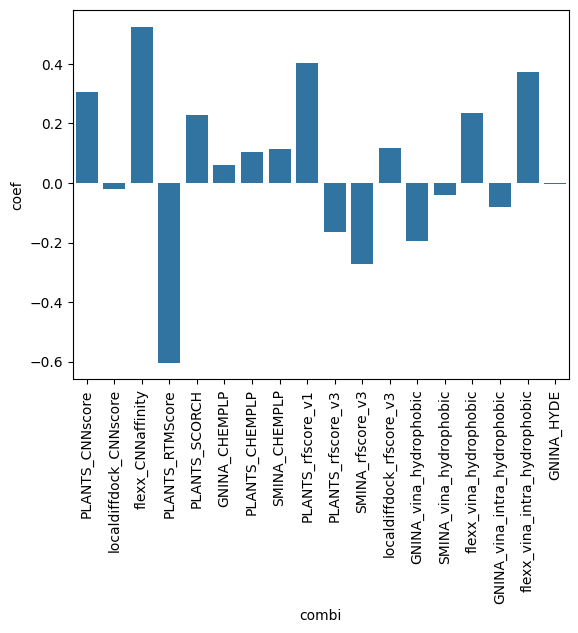

In [213]:
data = pd.DataFrame({
    'coef': reg.coef_,
    'combi': cols,
})
data = data[data['coef'] != 0]
sns.barplot(
    data,
    y='coef', 
    x='combi',
)
plt.xticks(rotation=90);

# Bilinear model

In [275]:
meta_cols = ["true_value", "activity_class", "pose"]
score_cols = [c for c in df.columns if c not in meta_cols]

docking_tools = sorted(df.index.get_level_values("docking_tool").unique())
score_names = sorted(score_cols)

n_docking = len(docking_tools)
n_scores = len(score_names)

ids = df.index.get_level_values("id").unique()

X = np.zeros((len(ids), len(docking_tools), len(score_names)))

for i, cid in enumerate(ids):
    sub = df.loc[cid] # (n_d, n_s)
    sub = sub.reindex(docking_tools)[score_names]
    X[i] = sub.values

y = df.groupby("id")["true_value"].first().loc[ids].values

X = np.nan_to_num(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [220]:
import torch
import torch.nn as nn

class BilinearModel(nn.Module):
    def __init__(self, n_docking, n_scores):
        super().__init__()
        self.w_d = nn.Parameter(torch.randn(n_docking))
        self.w_s = nn.Parameter(torch.randn(n_scores))

    def forward(self, X):
        # X: (N, D, S)
        return (X * self.w_d[None, :, None] * self.w_s[None, None, :]).sum(dim=(1, 2))

In [221]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import tqdm

def train_once(alpha, X_train, y_train, n_docking, n_scores,
               docking_tools, score_names, n_epochs=3000, n_runs=1, pbar=False):
    best_loss = float('inf')
    best_model = None

    jobs = range(n_runs)
    for _ in (tqdm.tqdm(jobs) if pbar else jobs):
        model = BilinearModel(n_docking, n_scores)
        opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    
        lambda_d = torch.tensor([_cost[t.lower()] for t in docking_tools], dtype=torch.float32)
        lambda_s = torch.tensor([_cost[t.lower()] for t in score_names], dtype=torch.float32)
    
        for _ in range(n_epochs):
            opt.zero_grad()
    
            y_pred = model(X_train)
            mse = ((y_pred - y_train) ** 2).mean()
    
            l1 = (lambda_d * model.w_d.abs()).sum() + (lambda_s * model.w_s.abs()).sum()
            loss = mse + alpha * l1
    
            loss.backward()
            opt.step()
        
        if loss < best_loss:
            best_model = model
            best_loss = loss

    return best_model

In [222]:
def run_single(alpha, run,
               X_train, y_train, X_test, y_test,
               n_docking, n_scores,
               docking_tools, score_names, n_runs=5):

    model = train_once(
        alpha, X_train, y_train,
        n_docking, n_scores,
        docking_tools, score_names,
        n_runs=n_runs,
    )

    wd = model.w_d.detach().cpu().numpy()
    ws = model.w_s.detach().cpu().numpy()

    mse_train = ((model(X_train) - y_train) ** 2).mean().item()
    mse_test = ((model(X_test) - y_test) ** 2).mean().item()

    corr_train = torch.corrcoef(torch.stack((model(X_train), y_train)))[0, 1].item()
    corr_test = torch.corrcoef(torch.stack((model(X_test), y_test)))[0, 1].item()

    wd_abs = np.abs(wd)
    ws_abs = np.abs(ws)

    return {
        "alpha": alpha,
        "run": run,
        "mse_train": mse_train,
        "mse_test": mse_test,
        "corr_train": corr_train,
        "corr_test": corr_test,
        **{f"wd_{t}": v for t, v in zip(docking_tools, wd_abs)},
        **{f"ws_{s}": v for s, v in zip(score_names, ws_abs)},
    }

In [224]:
from joblib import Parallel, delayed

alphas = [0] + list(np.logspace(-5, 0, 20))
n_runs = 10

tasks = [
    (alpha, run)
    for alpha in alphas
    for run in range(n_runs)
]

rows = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_single)(
        alpha, run,
        X_train, y_train, X_test, y_test,
        n_docking, n_scores,
        docking_tools, score_names, n_runs=10
    )
    for alpha, run in tqdm.tqdm(tasks)
)

df_weights = pd.DataFrame(rows)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 210/210 [23:07<00:00,  6.61s/it]


In [225]:
threshold = 5e-3

df_sel = df_weights.copy()

for t in docking_tools:
    df_sel[f"sel_{t}"] = (df_sel[f"wd_{t}"] > threshold).astype(int)

for s in score_names:
    df_sel[f"sel_{s}"] = (df_sel[f"ws_{s}"] > threshold).astype(int)

In [226]:
df_sel.columns

Index(['alpha', 'run', 'mse_train', 'mse_test', 'corr_train', 'corr_test',
       'wd_GNINA', 'wd_PLANTS', 'wd_SMINA', 'wd_flexx', 'wd_localdiffdock',
       'ws_CHEMPLP', 'ws_CNNaffinity', 'ws_CNNscore', 'ws_HYDE', 'ws_LinF9',
       'ws_RTMScore', 'ws_SCORCH', 'ws_rfscore_v1', 'ws_rfscore_v3',
       'ws_vina_hydrophobic', 'ws_vina_intra_hydrophobic', 'sel_GNINA',
       'sel_PLANTS', 'sel_SMINA', 'sel_flexx', 'sel_localdiffdock',
       'sel_CHEMPLP', 'sel_CNNaffinity', 'sel_CNNscore', 'sel_HYDE',
       'sel_LinF9', 'sel_RTMScore', 'sel_SCORCH', 'sel_rfscore_v1',
       'sel_rfscore_v3', 'sel_vina_hydrophobic', 'sel_vina_intra_hydrophobic'],
      dtype='str')

In [227]:
def compute_cost(row):
    return sum(
        _cost[t.lower()]
        for t in (docking_tools + score_names)
        if row[f"sel_{t}"] == 1
    )

df_sel["pipeline_cost"] = df_sel.apply(compute_cost, axis=1)

In [228]:
agg = df_sel.groupby("alpha").agg(["mean", "std"])
agg.columns = ["_".join(col) for col in agg.columns]
agg = agg.reset_index()

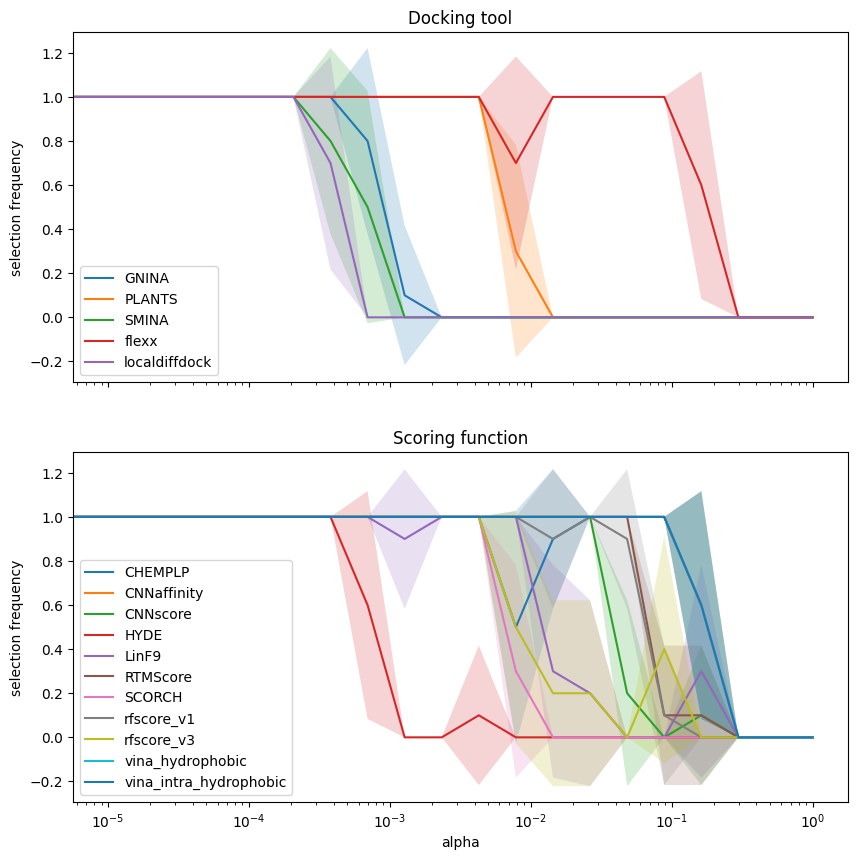

In [229]:
fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(10, 10))

for t in docking_tools:
    mean = agg[f"sel_{t}_mean"]
    std  = agg[f"sel_{t}_std"]

    ax1.plot(agg["alpha"], mean, label=t)
    ax1.fill_between(
        agg["alpha"],
        mean - std,
        mean + std,
        alpha=0.2
    )


for t in score_names:
    mean = agg[f"sel_{t}_mean"]
    std  = agg[f"sel_{t}_std"]

    ax2.plot(agg["alpha"], mean, label=t)
    ax2.fill_between(
        agg["alpha"],
        mean - std,
        mean + std,
        alpha=0.2
    )

ax1.set_xscale("log")
ax2.set_xlabel("alpha")
ax1.set_ylabel("selection frequency")
ax2.set_ylabel("selection frequency")
ax1.set_title("Docking tool")
ax2.set_title("Scoring function")
ax1.legend()
ax2.legend()
plt.show()

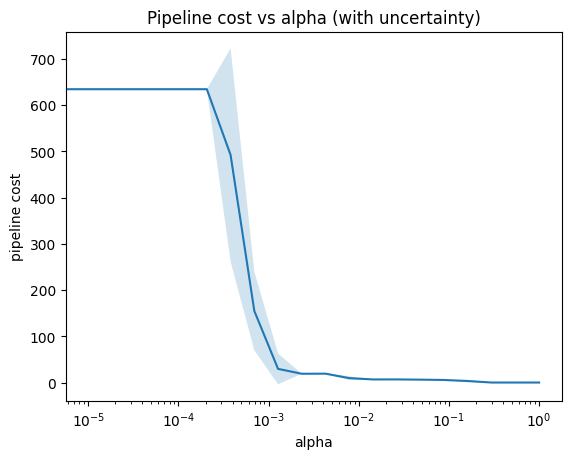

In [230]:
plt.figure()

mean = agg["pipeline_cost_mean"]
std  = agg["pipeline_cost_std"]

plt.plot(agg["alpha"], mean)
plt.fill_between(
    agg["alpha"],
    mean - std,
    mean + std,
    alpha=0.2
)

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("pipeline cost")
plt.title("Pipeline cost vs alpha (with uncertainty)")
plt.show()

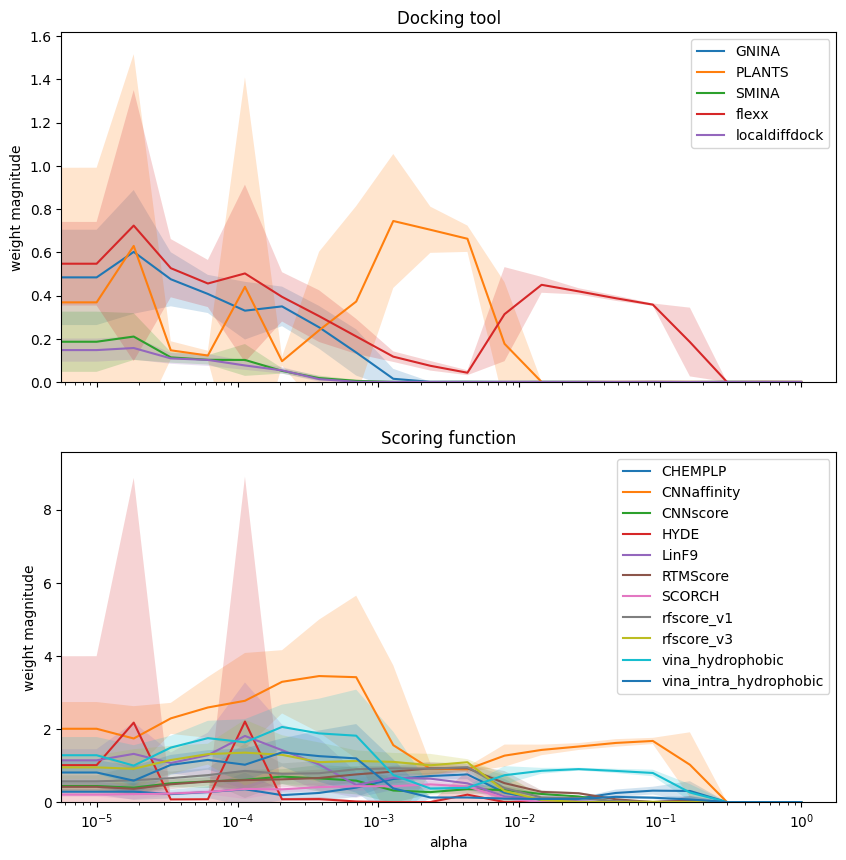

In [237]:
agg = df_sel.abs().groupby("alpha").agg(["mean", "std"])
agg.columns = ["_".join(col) for col in agg.columns]
agg = agg.reset_index()

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True, sharey=False, figsize=(10, 10))

for t in docking_tools:
    mean = agg[f"wd_{t}_mean"]
    std  = agg[f"wd_{t}_std"]

    ax1.plot(agg["alpha"], mean, label=t)
    ax1.fill_between(
        agg["alpha"],
        mean - std,
        mean + std,
        alpha=0.2
    )


for t in score_names:
    mean = agg[f"ws_{t}_mean"]
    std  = agg[f"ws_{t}_std"]

    ax2.plot(agg["alpha"], mean, label=t)
    ax2.fill_between(
        agg["alpha"],
        mean - std,
        mean + std,
        alpha=0.2
    )

ax1.set_xscale("log")
ax2.set_xlabel("alpha")
ax1.set_ylabel("weight magnitude")
ax2.set_ylabel("weight magnitude")
ax1.set_title("Docking tool")
ax2.set_title("Scoring function")
ax1.set_ylim(0, None)
ax2.set_ylim(0, None)
ax1.legend()
ax2.legend()
plt.show()

In [238]:
thresholds = np.logspace(-5, -1, 10)

threshold_results = []

for thr in thresholds:
    df_tmp = df_weights.copy()

    for t in docking_tools:
        df_tmp[f"sel_{t}"] = (df_sel[f"wd_{t}"] > thr).astype(int)
    
    for s in score_names:
        df_tmp[f"sel_{s}"] = (df_sel[f"ws_{s}"] > thr).astype(int)

    df_tmp["pipeline_cost"] = df_tmp.apply(
        compute_cost,
        axis=1
    )

    grouped = df_tmp.groupby("alpha")["pipeline_cost"].agg(["mean", "std"]).reset_index()
    grouped["threshold"] = thr

    threshold_results.append(grouped)

df_threshold = pd.concat(threshold_results)

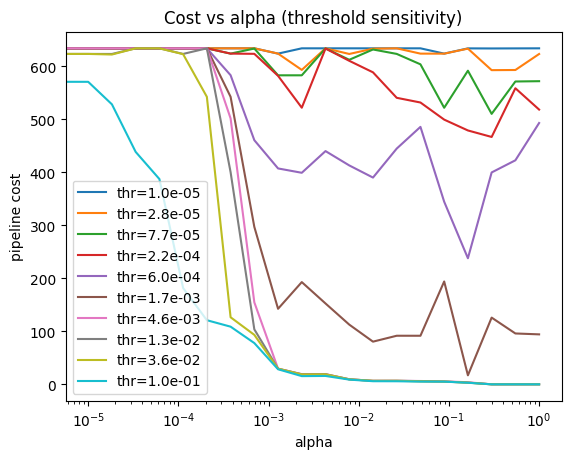

In [239]:
plt.figure()

for thr in thresholds:
    sub = df_threshold[df_threshold["threshold"] == thr]
    plt.plot(sub["alpha"], sub["mean"], label=f"thr={thr:.1e}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("pipeline cost")
plt.title("Cost vs alpha (threshold sensitivity)")
plt.legend()
plt.show()

In [240]:
df_sel["n_tools"] = df_sel[[f"sel_{t}" for t in (score_names + docking_tools)]].sum(axis=1)

pareto = df_sel.groupby("alpha").agg({
    "pipeline_cost": ["mean", "std"],
    "n_tools": ["mean", "std"]
})

pareto.columns = ["_".join(col) for col in pareto.columns]
pareto = pareto.reset_index()

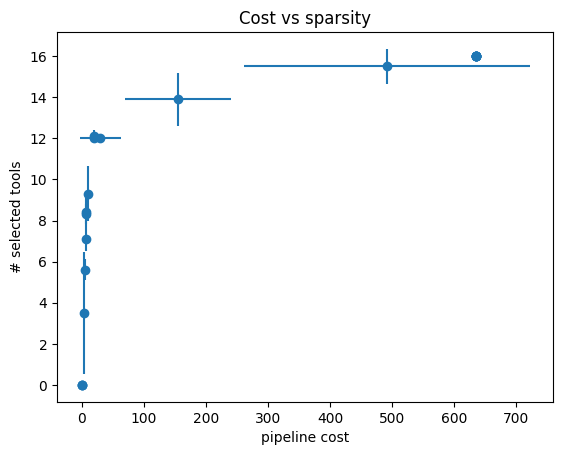

In [241]:
plt.figure()

plt.errorbar(
    pareto["pipeline_cost_mean"],
    pareto["n_tools_mean"],
    xerr=pareto["pipeline_cost_std"],
    yerr=pareto["n_tools_std"],
    fmt="o"
)

plt.xlabel("pipeline cost")
plt.ylabel("# selected tools")
plt.title("Cost vs sparsity")
plt.show()

In [242]:
perf = df_sel.groupby("alpha").agg({
    "pipeline_cost": ["mean", "std"],
    "mse_train": ["mean", "std"],
    "mse_test": ["mean", "std"],
})

perf.columns = ["_".join(col) for col in perf.columns]
perf = perf.reset_index()

In [252]:
perf

,alpha,pipeline_cost_mean,pipeline_cost_std,mse_train_mean,mse_train_std,mse_test_mean,mse_test_std
0,0.000000,634.1530,0.000000,0.509995,0.001231,0.809680,0.004748
1,0.000010,634.1530,0.000000,0.508521,0.003457,0.778924,0.096672
2,0.000018,634.1530,0.000000,0.505248,0.016529,0.726388,0.131421
3,0.000034,634.1530,0.000000,0.511050,0.002872,0.802409,0.008737
4,0.000062,634.1530,0.000000,0.510686,0.001786,0.800010,0.009693
5,0.000113,634.1530,0.000000,0.506974,0.016381,0.739047,0.120755
6,0.000207,634.1530,0.000000,0.513348,0.003122,0.791473,0.006222
7,0.000379,491.9230,230.620429,0.522689,0.007857,0.731718,0.106425
8,0.000695,154.7430,85.189546,0.530680,0.009167,0.670701,0.137922
9,0.001274,29.5090,33.381003,0.541365,0.005402,0.532652,0.089918


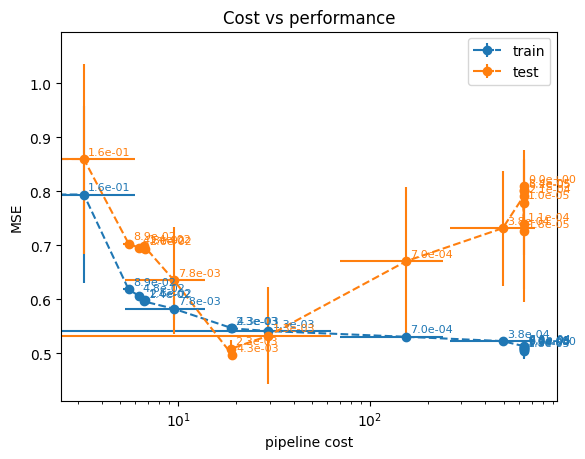

In [258]:
plt.figure()

train_plot = plt.errorbar(
    perf["pipeline_cost_mean"],
    perf["mse_train_mean"],
    xerr=perf["pipeline_cost_std"],
    yerr=perf["mse_train_std"],
    fmt="--o",
    label="train",
)

train_color = train_plot.lines[0].get_color()

for x, y, a in zip(
    perf["pipeline_cost_mean"],
    perf["mse_train_mean"],
    perf["alpha"]
):
    plt.annotate(
        f"{a:.1e}",
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        color=train_color,
        fontsize=8
    )



test_plot = plt.errorbar(
    perf["pipeline_cost_mean"],
    perf["mse_test_mean"],
    xerr=perf["pipeline_cost_std"],
    yerr=perf["mse_test_std"],
    fmt="--o",
    label="test",
)

test_color = test_plot.lines[0].get_color()

for x, y, a in zip(
    perf["pipeline_cost_mean"],
    perf["mse_test_mean"],
    perf["alpha"]
):
    plt.annotate(
        f"{a:.1e}",
        (x, y),
        textcoords="offset points",
        xytext=(3, 3),
        color=test_color,
        fontsize=8
    )


plt.legend()
plt.xlabel("pipeline cost")
plt.xscale('log')
plt.ylabel("MSE")
plt.title("Cost vs performance")
plt.show()

# No regularization

In [264]:
model = train_once(
    4.3e-3, X_train, y_train,
    n_docking, n_scores,
    docking_tools, score_names, n_runs=10, pbar=True,
)
mse_train = ((model(X_train) - y_train) ** 2).mean().item()
mse_test = ((model(X_test) - y_test) ** 2).mean().item()
corr_train = torch.corrcoef(torch.stack((model(X_train), y_train)))[0,1].item()
corr_test = torch.corrcoef(torch.stack((model(X_test), y_test)))[0,1].item()

corr_train, corr_test

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:18<00:00,  1.86s/it]


(0.6675834655761719, 0.7685236930847168)

In [265]:
mse_train, mse_test

(0.5457400679588318, 0.49073344469070435)

In [266]:
corr_train, corr_test

(0.6675834655761719, 0.7685236930847168)

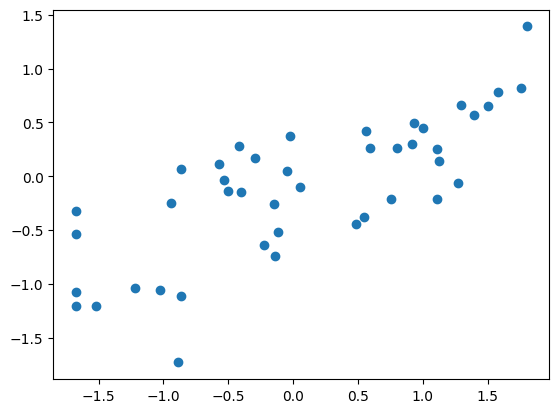

In [267]:
plt.scatter(y_test.flatten().detach().numpy(), model(X_test).flatten().detach().numpy())

In [268]:
wd = model.w_d.detach().cpu().numpy()
ws = model.w_s.detach().cpu().numpy()
print("Docking tools:")
print("\n".join([f" {t:<8}: {w:.5e}" for t, w in zip(docking_tools, wd)]))
print("Scoring functions:")
print("\n".join([f" {t:<22}: {w:.5e}" for t, w in zip(score_names, ws)]))

Docking tools:
 GNINA   : 1.73443e-03
 PLANTS  : -6.68314e-01
 SMINA   : 1.46335e-03
 flexx   : 4.58776e-02
 localdiffdock: 6.52147e-04
Scoring functions:
 CHEMPLP               : -7.02938e-01
 CNNaffinity           : -9.66892e-01
 CNNscore              : -3.08141e-01
 HYDE                  : 2.86606e-04
 LinF9                 : -5.73870e-01
 RTMScore              : 9.33208e-01
 SCORCH                : -4.29043e-01
 rfscore_v1            : -9.49365e-01
 rfscore_v3            : 1.09978e+00
 vina_hydrophobic      : -3.46199e-01
 vina_intra_hydrophobic: -1.52935e-01


# Weighted ECR

In [276]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class WeightedExpConsensusModel(nn.Module):
    def __init__(self, n_docking, n_scores, eps=1e-8):
        super().__init__()
        
        self.w_d_raw = nn.Parameter(torch.zeros(n_docking))
        self.w_s_raw = nn.Parameter(torch.zeros(n_scores))
        
        self.eps = eps

    def forward(self, R):
        """
        R: (N, D, S) = ranks r_ij
        """
        w_d = F.softplus(self.w_d_raw) + self.eps   # (D,)
        w_s = F.softplus(self.w_s_raw) + self.eps   # (S,)

        sigma = w_d[None, :, None] * w_s[None, None, :]  # (1, D, S)

        term = (1.0 / sigma) * torch.exp(-R / sigma)

        return term.sum(dim=(1, 2))

In [277]:
def soft_rank(x, tau=1.0):
    """
    x: (N,)
    returns approximate ranks (N,)
    """
    x = x.unsqueeze(0)  # (1, N)
    diff = x.transpose(1, 0) - x  # (N, N)

    P = torch.sigmoid(-diff / tau)  # pairwise comparisons
    return P.sum(dim=offset fontsize1) + 0.5

def spearman_loss(y_pred, y_true, tau=1.0):
    r_pred = soft_rank(y_pred, tau)
    r_true = soft_rank(y_true, tau)

    # normalize
    r_pred = (r_pred - r_pred.mean()) / (r_pred.std() + 1e-8)
    r_true = (r_true - r_true.mean()) / (r_true.std() + 1e-8)

    # maximize correlation → minimize negative correlation
    return - (r_pred * r_true).mean()


def pearson_loss(y_pred, y_true):
    y_pred = y_pred - y_pred.mean()
    y_true = y_true - y_true.mean()

    y_pred = y_pred / (y_pred.std() + 1e-8)
    y_true = y_true / (y_true.std() + 1e-8)

    return - (y_pred * y_true).mean()
def train_wecr_once(alpha, R_train, y_train, n_docking, n_scores,
               docking_tools, score_names, n_epochs=3000, n_runs=1, pbar=False):
    best_loss = float('inf')
    best_model = None

    jobs = range(n_runs)
    for _ in (tqdm.tqdm(jobs) if pbar else jobs):
        model = WeightedExpConsensusModel(n_docking, n_scores)
        opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    
        lambda_d = torch.tensor([_cost[t.lower()] for t in docking_tools], dtype=torch.float32)
        lambda_s = torch.tensor([_cost[t.lower()] for t in score_names], dtype=torch.float32)
    
        for _ in range(n_epochs):
            opt.zero_grad()

            y_pred = model(R_train)
            # y_pred = (y_pred - y_pred.mean()) / (y_pred.std() + 1e-8)
            loss = pearson_loss(y_pred, y_train)
            # print(np.corrcoef(y_pred.detach().numpy(), y_train.detach().numpy())[1,0])
    
            # l1 = (lambda_d * model.w_d.abs()).sum() + (lambda_s * model.w_s.abs()).sum()
            # loss = mse + alpha * l1
    
            loss.backward()
            opt.step()
        
        if loss < best_loss:
            best_model = model
            best_loss = loss

    return best_model

In [285]:
X = np.nan_to_num(X)
N, D, S = len(X), n_docking, n_scores
assert X.shape == (N, D, S)
X_flat = X.reshape(N, D * S)

R_flat = np.argsort(X_flat, axis=0) + 1

R = R_flat.reshape(N, D, S).astype(np.float32)

R_train, R_test, y_train, y_test = train_test_split(R, y, test_size=0.2)

R_train = torch.tensor(R_train, dtype=torch.float32)
R_test  = torch.tensor(R_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [286]:
ecr_model = train_wecr_once(0, R_train, y_train, n_docking, n_scores, docking_tools, score_names, n_runs=5, pbar=True)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:15<00:00,  3.10s/it]


In [287]:
corr_train = torch.corrcoef(torch.stack((ecr_model(R_train), y_train)))[0,1].item()
corr_test = torch.corrcoef(torch.stack((ecr_model(R_test), y_test)))[0,1].item()

corr_train, corr_test

(0.3455032408237457, -0.06222724914550781)

In [290]:
F.softplus(ecr_model.w_d_raw), F.softplus(ecr_model.w_s_raw)

(tensor([ 0.0140, 10.1468,  0.0124, 10.9349,  1.3059],
        grad_fn=<SoftplusBackward0>),
 tensor([1.5017e+01, 6.2688e-03, 2.4864e-02, 1.6658e-02, 2.0546e-02, 7.1563e+00,
         7.0713e-03, 1.7310e-02, 1.2207e-02, 5.7834e-03, 1.9221e-02],
        grad_fn=<SoftplusBackward0>))